In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import squidpy as sq
from SpaceFlow import SpaceFlow
import scanpy as sc
from sklearn import metrics
import numpy as np
import pandas as pd

In [2]:
output_folder = r"C:/Users/tnfp1/banksy_py/sun/sample"

adata = sc.read_h5ad(os.path.join(output_folder, "testA1-2.h5ad"))

In [ ]:
sf = SpaceFlow.SpaceFlow(adata=adata)

adata_copy = adata.copy()
adata_copy.obsm['spatial'] = adata_copy.obsm['spatial'].to_numpy()

sf.adata_preprocessed = adata_copy
sf.spatial_graph = sf.graph_alpha(adata_copy.obsm['spatial'], n_neighbors=10)


sf.train(
    embedding_save_filepath="./A1-2embedding0.01.tsv",
    spatial_regularization_strength=0.01,
    z_dim=50,
    lr=1e-3,
    epochs=1000,
    max_patience=50,
    min_stop=100,
    random_seed=42,
    gpu=0,
    regularization_acceleration=True,
    edge_subset_sz=1000000
)


Epoch 2/1000, Loss: 1.3921661376953125
Epoch 12/1000, Loss: 1.2292348146438599
Epoch 22/1000, Loss: 0.9680882692337036
Epoch 32/1000, Loss: 0.663974940776825
Epoch 42/1000, Loss: 0.4818534255027771
Epoch 52/1000, Loss: 0.36294129490852356
Epoch 62/1000, Loss: 0.2766139507293701
Epoch 72/1000, Loss: 0.24553905427455902
Epoch 82/1000, Loss: 0.20339138805866241
Epoch 92/1000, Loss: 0.17209802567958832
Epoch 102/1000, Loss: 0.1531120389699936
Epoch 112/1000, Loss: 0.1681000292301178
Epoch 122/1000, Loss: 0.1365496665239334
Epoch 132/1000, Loss: 0.1261141151189804
Epoch 142/1000, Loss: 0.12042104452848434
Epoch 152/1000, Loss: 0.1160503402352333
Epoch 162/1000, Loss: 0.1164373904466629
Epoch 172/1000, Loss: 0.09845779836177826
Epoch 182/1000, Loss: 0.09657584875822067
Epoch 192/1000, Loss: 0.09752770513296127
Epoch 202/1000, Loss: 0.09124249964952469
Epoch 212/1000, Loss: 0.07571648806333542
Epoch 222/1000, Loss: 0.07417182624340057
Epoch 232/1000, Loss: 0.07538780570030212
Epoch 242/1000, 

array([[ 2.7802017e-01,  1.4164914e+00,  5.1136836e-02, ...,
         4.7984412e-01, -1.0862164e-01,  5.2751452e-01],
       [-5.8358580e-02,  1.4255934e+00, -2.4450205e-01, ...,
         4.4779882e-01,  1.2925167e-01,  7.8454632e-03],
       [ 3.2922298e-01,  1.0776691e+00,  9.2940116e-01, ...,
         8.3242577e-01,  4.1140076e-02,  1.6167715e-01],
       ...,
       [ 1.4464475e+00,  4.8631254e-01,  4.4411692e-01, ...,
         1.1813576e+00,  3.1707981e-01,  6.5994281e-01],
       [ 1.6994539e+00,  1.6197922e+00,  4.5512536e-01, ...,
         1.1343658e+00, -5.2397363e-02,  9.3456644e-01],
       [ 6.2539887e-01,  5.0872612e-01, -2.3522249e-01, ...,
         5.8415443e-01,  2.7699611e-01,  6.4679008e-04]], dtype=float32)

In [5]:
sf.segmentation(domain_label_save_filepath="./A1-2domains0.01.tsv", n_neighbors=50, resolution=0.9)

Performing domain segmentation
Segmentation complete, domain labels of cells or spots saved at ./A1-2domains0.01.tsv !


In [6]:
sf.plot_segmentation(segmentation_figure_save_filepath="./A1-2domain0.01_segmentation.pdf", colormap="tab20", scatter_sz=1., rsz=4., csz=4., wspace=.4, hspace=.5, left=0.125, right=0.9, bottom=0.1, top=0.9)

Plotting complete, segmentation figure saved at ./A1-2domain0.01_segmentation.pdf !


In [7]:
import pandas as pd
import numpy as np

domains = np.loadtxt('./A1-2domains0.01.tsv', dtype=int)

print(f"domains length: {len(domains)}, adata shape[0]: {adata.shape[0]}")

adata.obs['spaceflow_clustering0.01'] = pd.Categorical(domains)


domains length: 8695, adata shape[0]: 8695


In [8]:
adata.obs['spaceflow_clustering0.01']

cells
35       5
37       7
38       2
39       7
41       5
        ..
18283    3
18377    0
18409    0
18472    0
18628    7
Name: spaceflow_clustering0.01, Length: 8695, dtype: category
Categories (11, int64): [0, 1, 2, 3, ..., 7, 8, 9, 10]

In [16]:
adata.write('./A1-2adata_spaceflow_clustering0.01.h5ad')

In [17]:
adata = sc.read_h5ad('./A1-2adata_spaceflow_clustering0.01.h5ad')

In [18]:
adata.obs['spaceflow_clustering0.01']

cells
35       5
37       7
38       2
39       7
41       5
        ..
18283    3
18377    0
18409    0
18472    0
18628    7
Name: spaceflow_clustering0.01, Length: 8695, dtype: category
Categories (11, int64): [0, 1, 2, 3, ..., 7, 8, 9, 10]

In [ ]:

adata = sc.read_h5ad('./A1-2adata_spaceflow_clustering0.01.h5ad')


embedding = np.loadtxt('A1-2embedding0.01.tsv', delimiter='\t')
assert embedding.shape[0] == adata.n_obs, "행 수 불일치!"


adata.obsm['X_spaceflow0.01'] = embedding

adata.write('adata_A1-2_spaceflow0.01.h5ad')

In [29]:
adata = sc.read_h5ad('./adata_A1-2_spaceflow0.01.h5ad')

▶ Plotting spaceflow_clustering0.01

Cluster Purity:
           Purity
Cluster          
0        0.675000
1        0.636159
2        0.597235
3        0.561181
4        0.616631
5        0.627700
6        0.709064
7        0.283159
8        0.705757
9        0.511785
10       0.400000


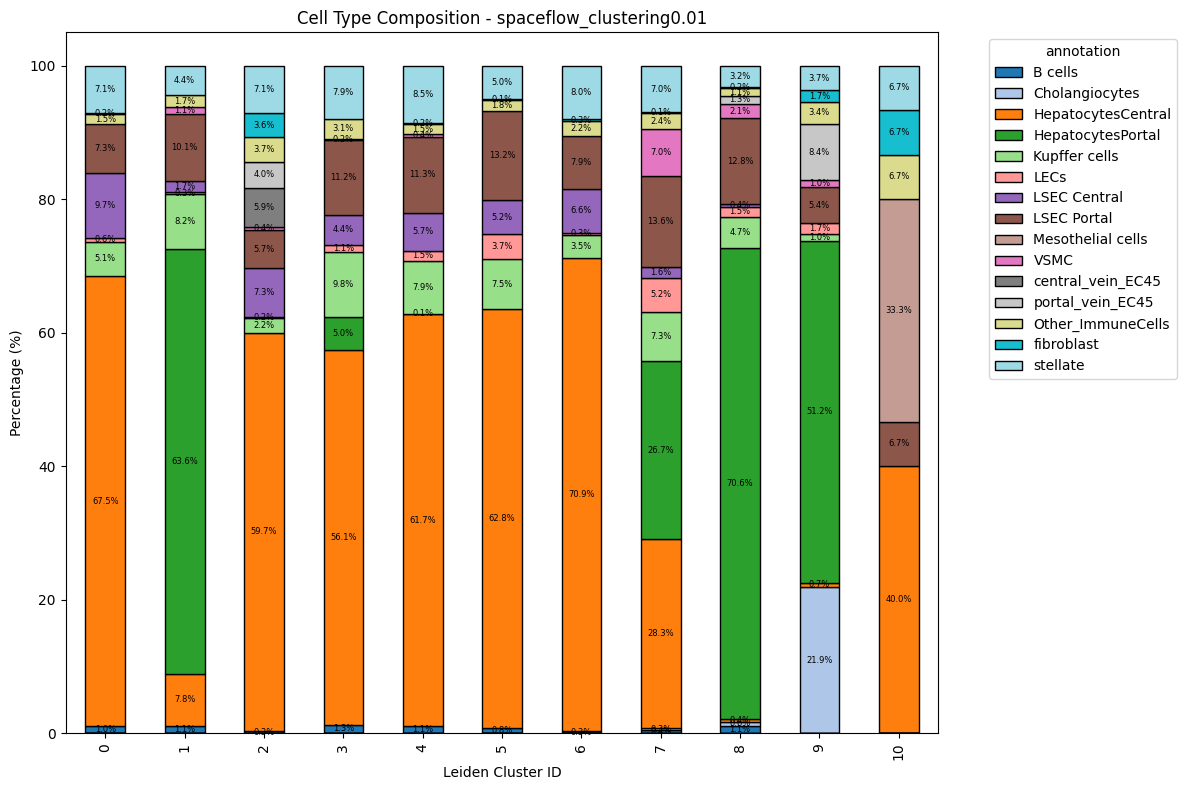

In [ ]:
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt

celltype_col = "annotation"
leiden_col = [col for col in adata.obs.columns if col.startswith("spaceflow_clustering")]

for cluster_col in leiden_col:
    print(f"▶ Plotting {cluster_col}")
    
    crosstab = pd.crosstab(adata.obs[cluster_col].astype("int32"), adata.obs[celltype_col])
    present_clusters = sorted(crosstab.index.astype(int))
    percent_table = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    purity_dict = {}
    for cluster_id, row in percent_table.loc[present_clusters].iterrows():
        max_percent = row.max()
        purity_dict[cluster_id] = max_percent / 100
    

    purity_df = pd.DataFrame.from_dict(purity_dict, orient='index', columns=['Purity'])
    purity_df.index.name = 'Cluster'
    purity_df = purity_df.sort_index()
    
    print("\nCluster Purity:")
    print(purity_df)

    ax = percent_table.loc[present_clusters].plot(
        kind='bar',
        stacked=True,
        figsize=(12, 8),
        colormap='tab20',
        edgecolor='black'
    )

    ax.set_xticks(range(len(present_clusters)))
    ax.set_xticklabels(present_clusters)

    plt.xlabel("Leiden Cluster ID")
    plt.ylabel("Percentage (%)")
    plt.title(f"Cell Type Composition - {cluster_col}")
    plt.legend(title=celltype_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    for bar_idx, (cluster_id, row) in enumerate(percent_table.loc[present_clusters].iterrows()):
        cum_height = 0
        for i, value in enumerate(row):
            if value > 0:
                height = value
                ax.text(
                    bar_idx,                  
                    cum_height + height / 2,  
                    f"{height:.1f}%",         
                    ha='center', va='center', fontsize=6, color='black'
                )
                cum_height += height
    filename = f"{cluster_col}_barplot.png"

    
    plt.show()


In [32]:
def plot_2d_embeddings_all(embedding, labels, ax,
                           method_str="UMAP", xlabel="UMAP 1", ylabel="UMAP 2",
                           cmap='tab20', pointsize=3,
                           show_legend=True, legend_loc='outside', label_fontsize=8):

    cmap_obj = get_cmap(cmap)
    label_ids = np.unique(labels)

    for i, label_id in enumerate(label_ids):
        mask = labels == label_id
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=[cmap_obj(i % 20)],
            s=pointsize,
            label=f"Cluster {label_id}",
            alpha=0.8
        )

    ax.set_title(f"{method_str}", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis('off')

    if show_legend:
        if legend_loc == 'outside':
            ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=label_fontsize)
        else:
            ax.legend(loc=legend_loc, fontsize=label_fontsize)

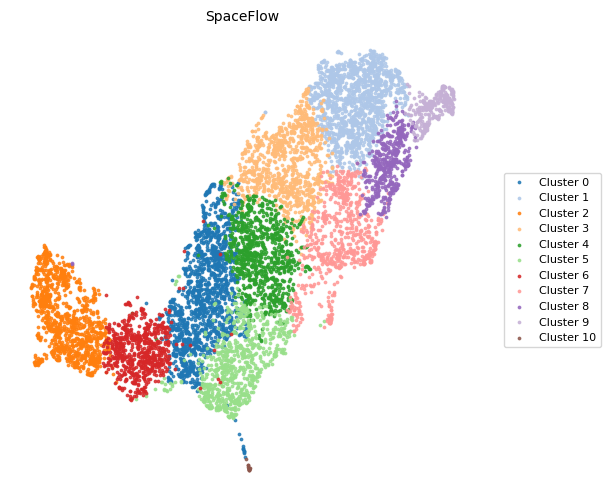

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_2d_embeddings_all(
    adata.obsm['X_spaceflow_umap0.01'],
    adata.obs['spaceflow_clustering0.01'],
    ax=ax,
    method_str="SpaceFlow",
    cmap='tab20'
)
plt.show()

In [34]:
def plot_2d_embeddings_annotated(embedding, annotations, ax,
                                  method_str="UMAP", cmap='tab20',
                                  pointsize=3, label_fontsize=5,
                                  show_legend=True, legend_loc='outside',
                                  show_text=False):

    celltypes = adata.obs['annotation'].unique()
    cmap_obj = get_cmap(cmap)
    palette = {ct: cmap_obj(i % 20) for i, ct in enumerate(celltypes)}

    for ct in celltypes:
        mask = annotations == ct
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=[palette[ct]] * np.sum(mask),
            s=pointsize,
            label=ct
        )

        # 중심 텍스트 생략 옵션
        if show_text:
            center_x = embedding[mask, 0].mean()
            center_y = embedding[mask, 1].mean()
            ax.text(center_x, center_y, ct,
                    fontsize=label_fontsize, weight='bold',
                    ha='center', va='center')

    ax.set_title(f'{method_str} with Cell Type Annotation')
    ax.axis('off')

    if show_legend:
        if legend_loc == 'outside':
            ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=label_fontsize)
        else:
            ax.legend(loc=legend_loc, fontsize=label_fontsize)

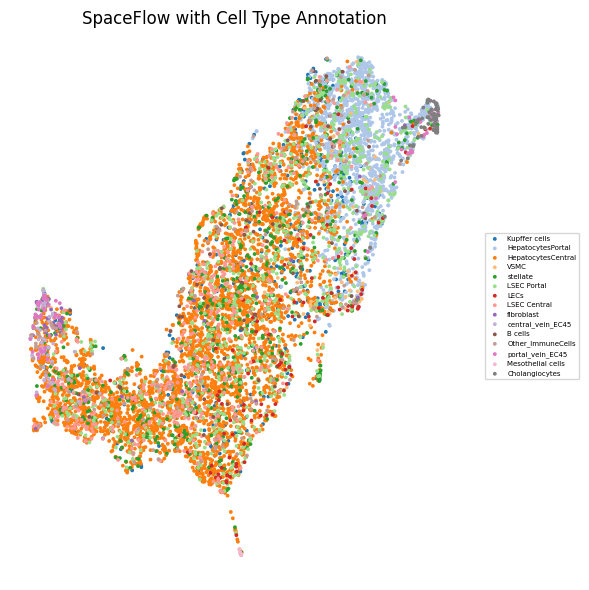

In [35]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_2d_embeddings_annotated(
    embedding=adata.obsm['X_spaceflow_umap0.01'],
    annotations=adata.obs['annotation'].values,
    ax=ax,
    method_str="SpaceFlow",
    cmap='tab20'
)
plt.tight_layout()
plt.show()


In [39]:
pc_genes = ["Glul", "Cyp2e1", "Wnt2", "Wnt9b"]
pp_genes = ["Sds", "Hal", "Ngfr", "Igfbp3", "Spp1", "Gja5", "Adgrg6", "Epcam"]

adata.obs['zonation_score'] = (
    adata[:, pc_genes].X.mean(axis=1) - adata[:, pp_genes].X.mean(axis=1)
).flatten()

zonation_scores_per_cell = adata.obs['zonation_score']

# Normalize zonation scores (min-max normalization)
min_score = np.min(zonation_scores_per_cell)
max_score = np.max(zonation_scores_per_cell)
if max_score > min_score:
    normalized_scores = (zonation_scores_per_cell - min_score) / (max_score - min_score)
else:
    normalized_scores = np.zeros_like(zonation_scores_per_cell)  # All same value

adata.obs['normalized_scores'] = normalized_scores

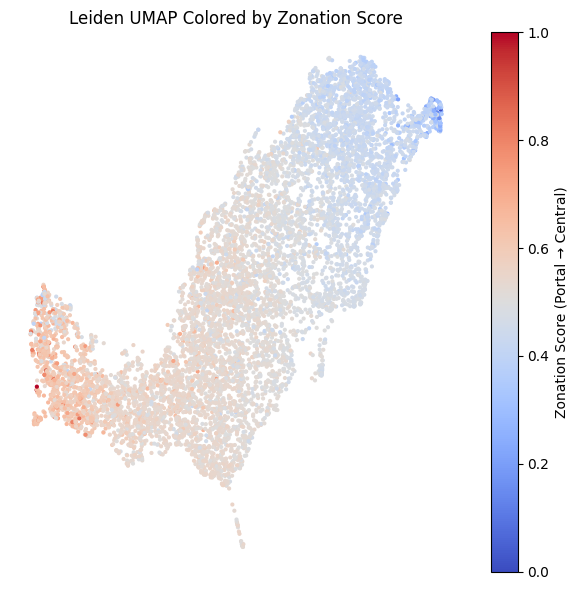

In [40]:
embedding = adata.obsm['X_spaceflow_umap0.01']
norm = plt.Normalize(vmin=0, vmax=1)
cmap = plt.get_cmap('coolwarm')  # blue (portal) → red (central)

zonation_scores_per_cell = adata.obs['zonation_score']

# Normalize zonation scores (min-max normalization)
min_score = np.min(zonation_scores_per_cell)
max_score = np.max(zonation_scores_per_cell)
if max_score > min_score:
    normalized_scores = (zonation_scores_per_cell - min_score) / (max_score - min_score)
else:
    normalized_scores = np.zeros_like(zonation_scores_per_cell)

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=cmap(normalized_scores),
    s=4
)

ax.set_title('Leiden UMAP Colored by Zonation Score')
ax.axis('off')

# Add colorbar
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Zonation Score (Portal → Central)')

plt.tight_layout()
plt.show()


In [41]:
def draw_umap_grid_for_all_clusters(embedding, cluster_labels, annotations, fixed_palette,
                                     method_str="UMAP",
                                     cmap='tab20',
                                     pointsize=4, background_alpha=0.03,
                                     n_cols=2, legend=False,
                                     figsize_per_row=(20, 5),
                                     save_path=None):
    """
    Grid version of draw_umap_for_all_clusters.
    For each cluster, draw (full UMAP + zoomed) side-by-side in a grid layout.

    Args:
        embedding: (N_cells, 2) array
        cluster_labels: array-like cluster assignments
        annotations: array-like cell type annotations
        fixed_palette: dict of annotation to fixed color
        method_str: title prefix
        n_cols: number of columns in the grid (must be even, as each cluster takes 2 columns)
        figsize_per_row: (width, height) per row in inches
        save_path: if provided, save final figure as one PNG
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.cm import get_cmap
    import math
    import os

    cluster_labels = np.array(cluster_labels)
    annotations = np.array(annotations)
    cluster_ids = np.unique(cluster_labels)

    # Each cluster uses 2 columns (full + zoom)
    assert n_cols % 2 == 0, "n_cols must be even to pair full+zoom plots"
    n_clusters = len(cluster_ids)
    n_rows = math.ceil(n_clusters * 2 / n_cols)

    figsize = (figsize_per_row[0], figsize_per_row[1] * n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    axes = axes.reshape(-1, n_cols)

    cmap_obj = get_cmap(cmap)

    for idx, cid in enumerate(cluster_ids):
        row = (idx * 2) // n_cols
        col_full = (idx * 2) % n_cols
        col_zoom = col_full + 1

        ax1 = axes[row][col_full]
        ax2 = axes[row][col_zoom]

        mask = cluster_labels == cid
        if np.sum(mask) == 0:
            continue

        # LEFT: full UMAP
        ax1.scatter(
            embedding[:, 0], embedding[:, 1],
            c='lightgray', alpha=background_alpha, s=pointsize
        )
        color = cmap_obj(cid % 20)
        ax1.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=[color] * np.sum(mask),
            s=pointsize + 1
        )
        ax1.set_title(f'{method_str} – Cluster {cid} (Full)', fontsize=9)
        ax1.axis('off')

        # RIGHT: zoomed view with annotation
        emb_subset = embedding[mask]
        annot_subset = annotations[mask]
        unique_annots = np.unique(annot_subset)

        for ct in unique_annots:
            submask = annot_subset == ct
            color = fixed_palette.get(ct, 'black')
            ax2.scatter(
                emb_subset[submask, 0],
                emb_subset[submask, 1],
                c=[color] * np.sum(submask),
                s=pointsize,
                label=ct
            )

        ax2.set_title(f'{method_str} – Cluster {cid} (Zoomed)', fontsize=9)
        ax2.axis('off')

        if legend:
            ax2.legend(markerscale=1.5, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


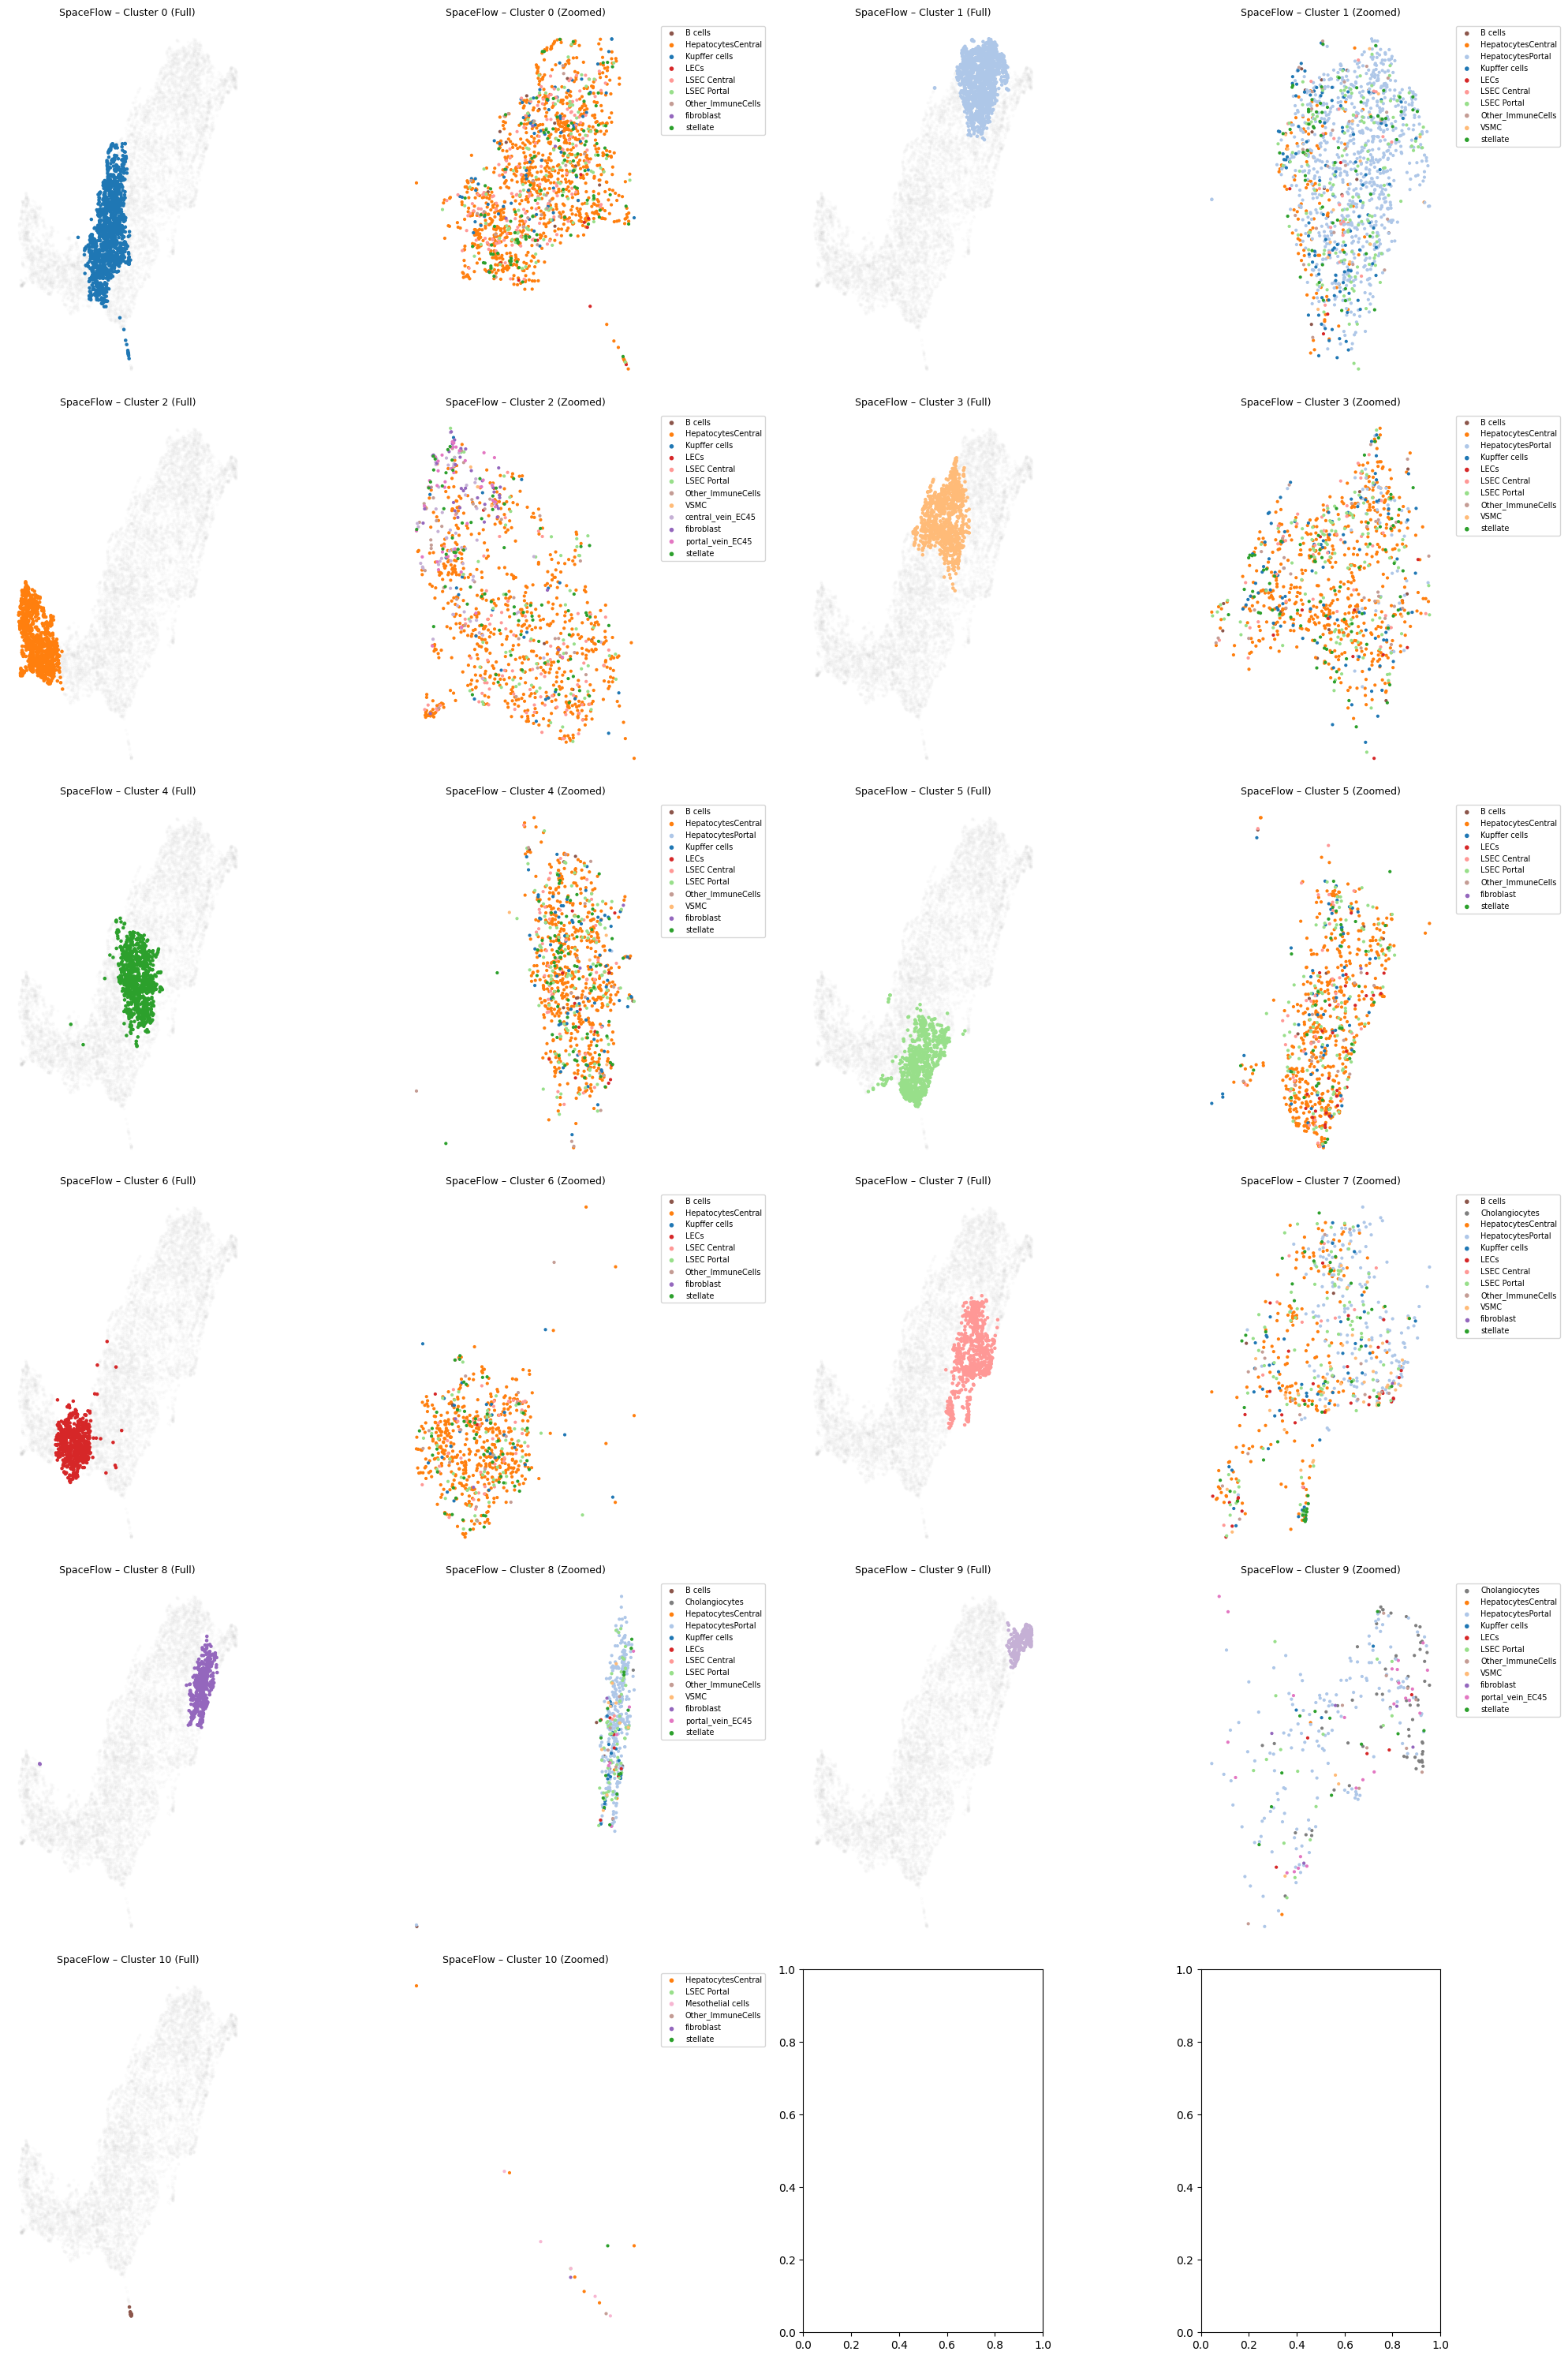

In [42]:
all_celltypes = adata.obs['annotation'].unique()
cmap = get_cmap('tab20')
fixed_palette = {ct: cmap(i % 20) for i, ct in enumerate(all_celltypes)}

draw_umap_grid_for_all_clusters(
    embedding=adata.obsm['X_spaceflow_umap0.01'],
    cluster_labels=adata.obs['spaceflow_clustering0.01'].astype('int32'),
    annotations=adata.obs['annotation'].values,
    fixed_palette=fixed_palette,
    method_str="SpaceFlow",
    cmap='tab20',
    pointsize=4,
    n_cols=4,  # must be even (each cluster uses 2 columns)
    legend=True
)

   cluster  zonation_score_variance
0        0                 0.001043
1        1                 0.000803
2        2                 0.005284
3        3                 0.001051
4        4                 0.000743
5        5                 0.000603
6        6                 0.001161
7        7                 0.000646
8        8                 0.000771
9        9                 0.006319
10      10                 0.000616


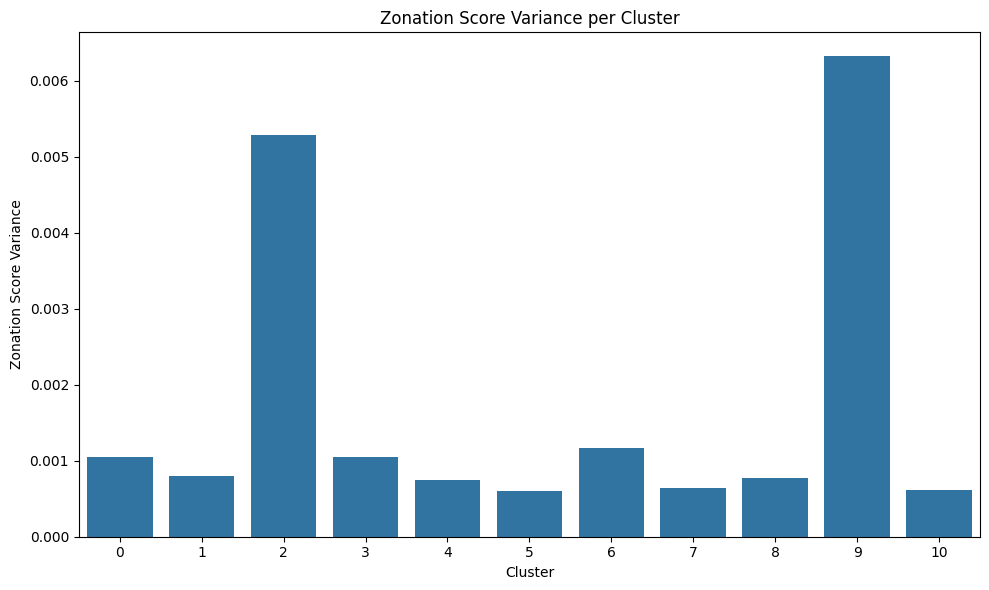

In [43]:
import seaborn as sns

cluster_labels = adata.obs['spaceflow_clustering0.01']
zonation_score_per_cell = adata.obs['normalized_scores']
adata.obs['cluster'] = cluster_labels

grouped = adata.obs.groupby('cluster')['normalized_scores']
cluster_variances = grouped.var().reset_index()
cluster_variances.columns = ['cluster', 'zonation_score_variance']

print(cluster_variances)

plt.figure(figsize=(10, 6))
sns.barplot(data=cluster_variances, x='cluster', y='zonation_score_variance', color='#1f77b4')
plt.xlabel("Cluster")
plt.ylabel("Zonation Score Variance")
plt.title("Zonation Score Variance per Cluster")
plt.xticks()
plt.tight_layout()
plt.show()


In [44]:
adata.obs['zonation_score']

cells
35       0.118254
37      -0.380687
38       0.438944
39      -0.445911
41       0.123945
           ...   
18283   -0.359698
18377    0.321435
18409    2.357008
18472    0.250454
18628    0.078618
Name: zonation_score, Length: 8695, dtype: float64

In [ ]:

cluster_col = 'spaceflow_clustering0.01' 

cluster_counts = adata.obs[cluster_col].value_counts().sort_index()

cluster_count_df = pd.DataFrame({
    'cluster_id': cluster_counts.index,
    'cell_count': cluster_counts.values
})

print(cluster_count_df)

   cluster_id  cell_count
0           0        1480
1           1        1333
2           2        1085
3           3         948
4           4         926
5           5         787
6           6         684
7           7         671
8           8         469
9           9         297
10         10          15


In [ ]:
def get_cluster_cell_counts(adata, cluster_col):
    cluster_counts = adata.obs[cluster_col].value_counts().sort_index()
    cluster_count_df = pd.DataFrame({
        'cluster_id': cluster_counts.index,
        'cell_count': cluster_counts.values
    }).reset_index(drop=True)
    return cluster_count_df

def calculate_total_zonation_variance(adata, zonation_score_col):
    zonation_scores = adata.obs[zonation_score_col].values
    total_variance = np.var(zonation_scores)
    return total_variance

def calculate_variance_based_purity(cluster_variances, cluster_counts, total_variance):
    cluster_variances = np.array(cluster_variances)
    cluster_counts = np.array(cluster_counts)
    total_cells = np.sum(cluster_counts)
    
    weighted_within_variance = np.sum(cluster_counts * cluster_variances)
    purity = 1 - (weighted_within_variance / (total_cells * total_variance))
    return purity

def calculate_cluster_variances(adata, cluster_col, zonation_score_col):
  
    cluster_labels = adata.obs[cluster_col].astype("int32")
    zonation_score_per_cell = adata.obs[zonation_score_col]
    adata.obs['cluster'] = cluster_labels
    
    grouped = adata.obs.groupby('cluster')[zonation_score_col]
    cluster_variances_df = grouped.var().reset_index()
    cluster_variances_df.columns = ['cluster', 'zonation_score_variance']
    
    return cluster_variances_df

In [ ]:
cluster_col = 'spaceflow_clustering0.01'
zonation_score_col = 'normalized_scores'


cluster_count_df = get_cluster_cell_counts(adata, cluster_col)
cluster_counts = cluster_count_df['cell_count'].values

total_variance = calculate_total_zonation_variance(adata, zonation_score_col)
print(f"Total zonation score variance: {total_variance:.4f}")

cluster_variances_df = calculate_cluster_variances(adata, cluster_col, zonation_score_col)
cluster_variances = cluster_variances_df['zonation_score_variance'].values


purity = calculate_variance_based_purity(cluster_variances, cluster_counts, total_variance)
print(f"{cluster_col} variance-based purity: {purity:.4f}")

Total zonation score variance: 0.0045
spaceflow_clustering0.01 variance-based purity: 0.6460
